Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Initializing GlassBox-ViT (AttentionRolloutExplainer)...
Loading and resizing test image (Chelsea the cat)...
 Generating Rollout explanation (Extracting attention matrices)...

 ROLLOUT TEST PASSED SUCCESSFULLY
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%


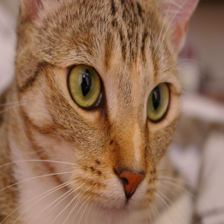

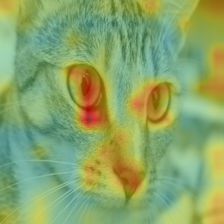

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data

# Importing our library
from glassbox_vit.rollout_explainer import AttentionRolloutExplainer

# --- MODEL SETUP  ---
print("Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)

# We request the model's internals (attentions)
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    output_attentions=True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# --- INITIALIZE LIBRARY ---
print(" Initializing GlassBox-ViT (AttentionRolloutExplainer)...")
# We pass the model and the processor directly
rollout_explainer = AttentionRolloutExplainer(
    model=model,
    processor=processor
)

# --- LOAD TEST IMAGE  ---
print("Loading and resizing test image (Chelsea the cat)...")
image_np = data.chelsea()
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# --- THE TEST ---
print(" Generating Rollout explanation (Extracting attention matrices)...")
# Just pass the photo.
result = rollout_explainer.generate(pil_image=test_image)

# --- DISPLAY RESULTS ---
# Extract label and probability
class_names = list(model.config.id2label.values())
predicted_class = class_names[result['predicted_label_id']]
probability = result['prediction_prob'] * 100

print("\n ROLLOUT TEST PASSED SUCCESSFULLY")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {probability:.2f}%")
display(test_image)
display(result['rollout_image'])
